---
**Title:** Tensor Parallelism (TP)

**Category:** tensor-parallelism

**Difficulty:** Intermediate

**Estimated Time:** 45 min

---

## Overview

When a model's layers are too large for one GPU, **Tensor Parallelism (TP)** splits each weight matrix across multiple GPUs.

This notebook builds up the idea step by step with real tensor examples:

1. Split a matrix by columns → **Column-Parallel**
2. Split a matrix by rows → **Row-Parallel**
3. Combine both into a **Conjugate Pair** (one AllReduce per block)
4. Apply to **MLP** and **Self-Attention**

### Prerequisites
- Basic PyTorch (tensor ops, matrix multiplication)
- [00-gpu-communication/](00-gpu-communication.ipynb) — especially **AllReduce** (every GPU sends its data to all others and gets back the sum) and **AllGather** (every GPU sends its data and gets back the full concatenation)

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from mp_tutorial.viz import show_matrix, show_matrices_row, draw_tensor_split, GPU_COLORS
from mp_tutorial.distributed import simulate_allreduce, simulate_allgather, check_gpu_env

check_gpu_env()
torch.manual_seed(42)

%matplotlib inline

✗ No CUDA GPU detected on this machine.

To run GPU-required cells, use a machine with CUDA GPUs (4+ recommended).
See README.md for remote Jupyter setup instructions.


---
## 1. The simplest case: one linear layer

A **linear layer** is the most basic building block in neural networks — it computes $Y = X \cdot W$, where $X$ is the input and $W$ is a **weight matrix** (a grid of learnable numbers). Training a model means adjusting these weight values.

Let's start with tiny tensors we can see entirely.

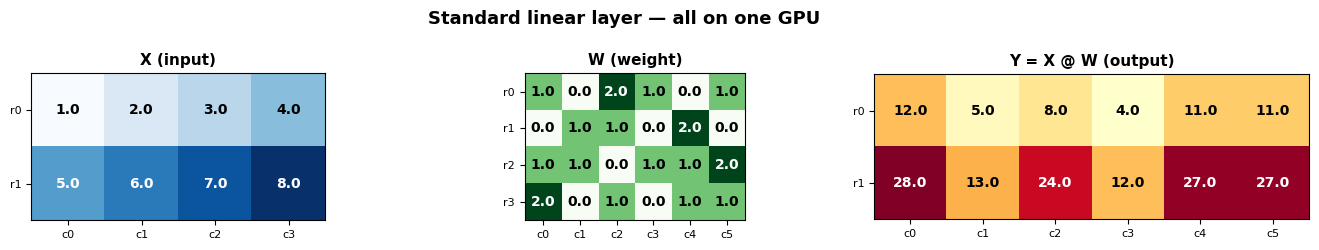

In [2]:
# A tiny linear layer: X (2×4) @ W (4×6) = Y (2×6)
X = torch.tensor([[1., 2., 3., 4.],
                   [5., 6., 7., 8.]])

W = torch.tensor([[1., 0., 2., 1., 0., 1.],
                   [0., 1., 1., 0., 2., 0.],
                   [1., 1., 0., 1., 1., 2.],
                   [2., 0., 1., 0., 1., 1.]])

Y = X @ W

fig, axes = plt.subplots(1, 3, figsize=(14, 2.5))
show_matrix(X, ax=axes[0], title="X (input)", cmap="Blues")
show_matrix(W, ax=axes[1], title="W (weight)", cmap="Greens")
show_matrix(Y, ax=axes[2], title="Y = X @ W (output)", cmap="YlOrRd")
fig.suptitle("Standard linear layer — all on one GPU", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

Now: what if $W$ is too big for one GPU? We need to **split** it.

---
## 2. Column-Parallel: split $W$ by columns

Divide $W$'s columns evenly across GPUs. Each GPU gets the full input $X$ and computes with its slice of $W$.

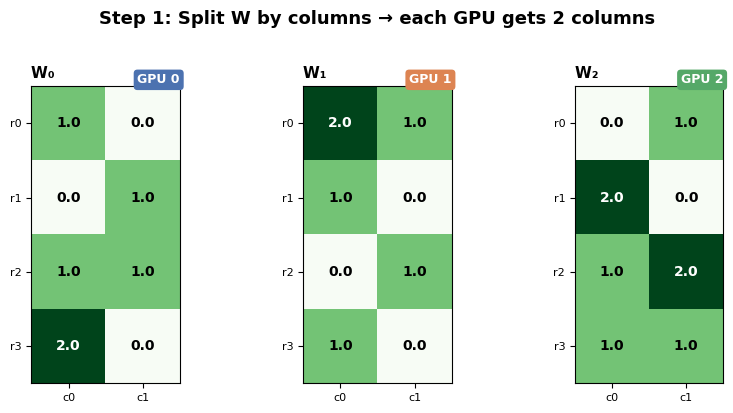

In [3]:
# Split W into 3 column chunks (simulating 3 GPUs)
num_gpus = 3
W_chunks = W.chunk(num_gpus, dim=1)  # split along columns

# Visualize the split
fig = show_matrices_row(
    W_chunks,
    titles=["W₀", "W₁", "W₂"],
    gpu_labels=["GPU 0", "GPU 1", "GPU 2"],
    suptitle="Step 1: Split W by columns → each GPU gets 2 columns",
    cmap="Greens"
)
plt.show()

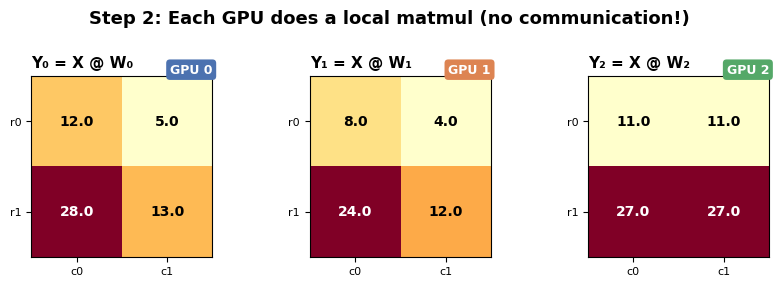

In [4]:
# Each GPU computes: Y_i = X @ W_i  (no communication needed!)
Y_parts = [X @ W_i for W_i in W_chunks]

fig = show_matrices_row(
    Y_parts,
    titles=["Y₀ = X @ W₀", "Y₁ = X @ W₁", "Y₂ = X @ W₂"],
    gpu_labels=["GPU 0", "GPU 1", "GPU 2"],
    suptitle="Step 2: Each GPU does a local matmul (no communication!)"
)
plt.show()

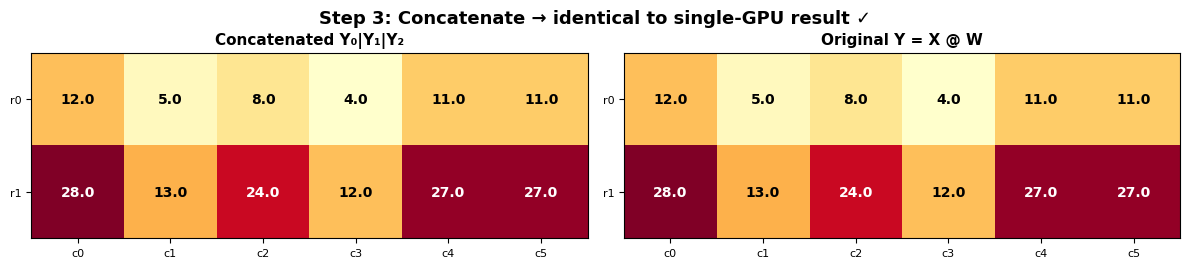

✓ Column-parallel matches!


In [5]:
# Concatenate to get the full output
Y_column = torch.cat(Y_parts, dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))
show_matrix(Y_column, ax=axes[0], title="Concatenated Y₀|Y₁|Y₂")
show_matrix(Y,        ax=axes[1], title="Original Y = X @ W")
fig.suptitle("Step 3: Concatenate → identical to single-GPU result ✓",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

assert torch.allclose(Y_column, Y)
print("✓ Column-parallel matches!")

**Key insight:** Column-parallel forward needs **zero communication**. Each GPU independently computes its output columns.

---
## 3. Row-Parallel: split $W$ by rows

Now we split $W$ along rows. This means we also need to split the **input** $X$ along its last dimension.

Unlike column-parallel, each GPU here produces a **partial sum** (same shape as the full output). To get the final result, we need **AllReduce** — a collective operation where every GPU sends its partial result to all others, and each GPU ends up with the total sum.

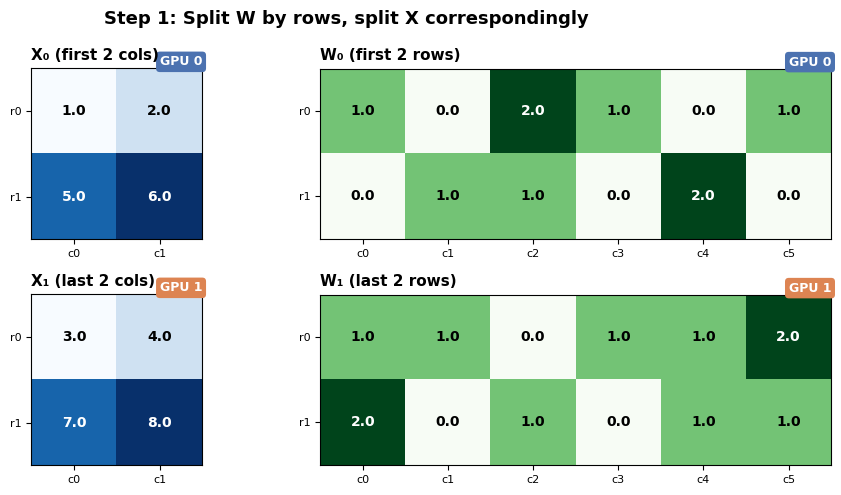

In [6]:
# Split W by rows and X by columns (last dim), 2 GPUs this time
num_gpus = 2
W_chunks = W.chunk(num_gpus, dim=0)  # split W along rows
X_chunks = X.chunk(num_gpus, dim=1)  # split X along columns

fig, axes = plt.subplots(2, 2, figsize=(10, 5))
show_matrix(X_chunks[0], ax=axes[0, 0], title="X₀ (first 2 cols)", gpu_label="GPU 0", cmap="Blues")
show_matrix(W_chunks[0], ax=axes[0, 1], title="W₀ (first 2 rows)", gpu_label="GPU 0", cmap="Greens")
show_matrix(X_chunks[1], ax=axes[1, 0], title="X₁ (last 2 cols)",  gpu_label="GPU 1", cmap="Blues")
show_matrix(W_chunks[1], ax=axes[1, 1], title="W₁ (last 2 rows)",  gpu_label="GPU 1", cmap="Greens")
fig.suptitle("Step 1: Split W by rows, split X correspondingly", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

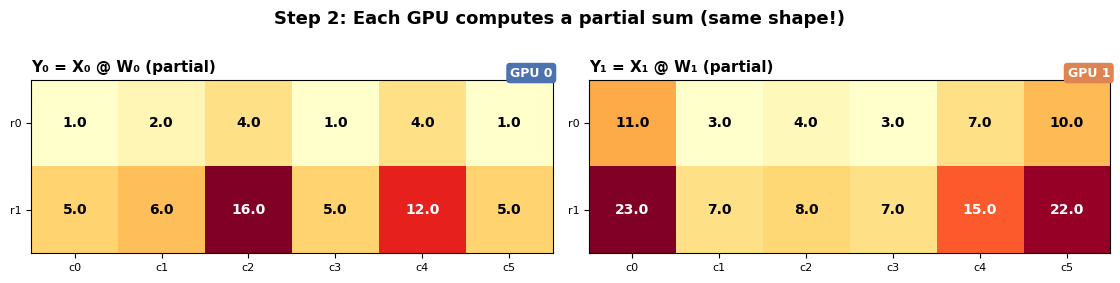

Notice: both partials have shape torch.Size([2, 6]) — same as the full output.
They are PARTIAL SUMS that need to be added together.


In [7]:
# Each GPU computes a PARTIAL result: Y_i = X_i @ W_i
Y_parts = [X_i @ W_i for X_i, W_i in zip(X_chunks, W_chunks)]

fig = show_matrices_row(
    Y_parts,
    titles=["Y₀ = X₀ @ W₀ (partial)", "Y₁ = X₁ @ W₁ (partial)"],
    gpu_labels=["GPU 0", "GPU 1"],
    suptitle="Step 2: Each GPU computes a partial sum (same shape!)"
)
plt.show()

print(f"Notice: both partials have shape {Y_parts[0].shape} — same as the full output.")
print("They are PARTIAL SUMS that need to be added together.")

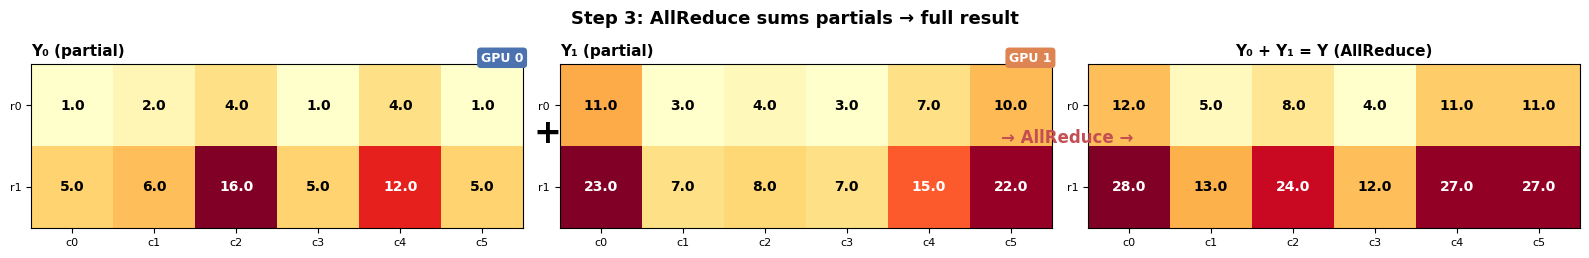

✓ Row-parallel matches!


In [8]:
# AllReduce: sum the partial results across all GPUs
Y_allreduced = simulate_allreduce(Y_parts)

fig, axes = plt.subplots(1, 3, figsize=(16, 2.5))
show_matrix(Y_parts[0],      ax=axes[0], title="Y₀ (partial)", gpu_label="GPU 0")
show_matrix(Y_parts[1],      ax=axes[1], title="Y₁ (partial)", gpu_label="GPU 1")
show_matrix(Y_allreduced[0], ax=axes[2], title="Y₀ + Y₁ = Y (AllReduce)")

# Add a "+" and "=" between plots
fig.text(0.345, 0.45, "+", fontsize=24, fontweight="bold", ha="center")
fig.text(0.67,  0.45, "→ AllReduce →", fontsize=12, fontweight="bold", ha="center",
         color="#C44E52")
fig.suptitle("Step 3: AllReduce sums partials → full result", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

assert torch.allclose(Y_allreduced[0], Y)
print("✓ Row-parallel matches!")

**Key insight:** Row-parallel needs one **AllReduce (sum)** to combine partial results.

---
## 4. Side-by-side comparison

Let's visualize both strategies in one diagram to see the difference.

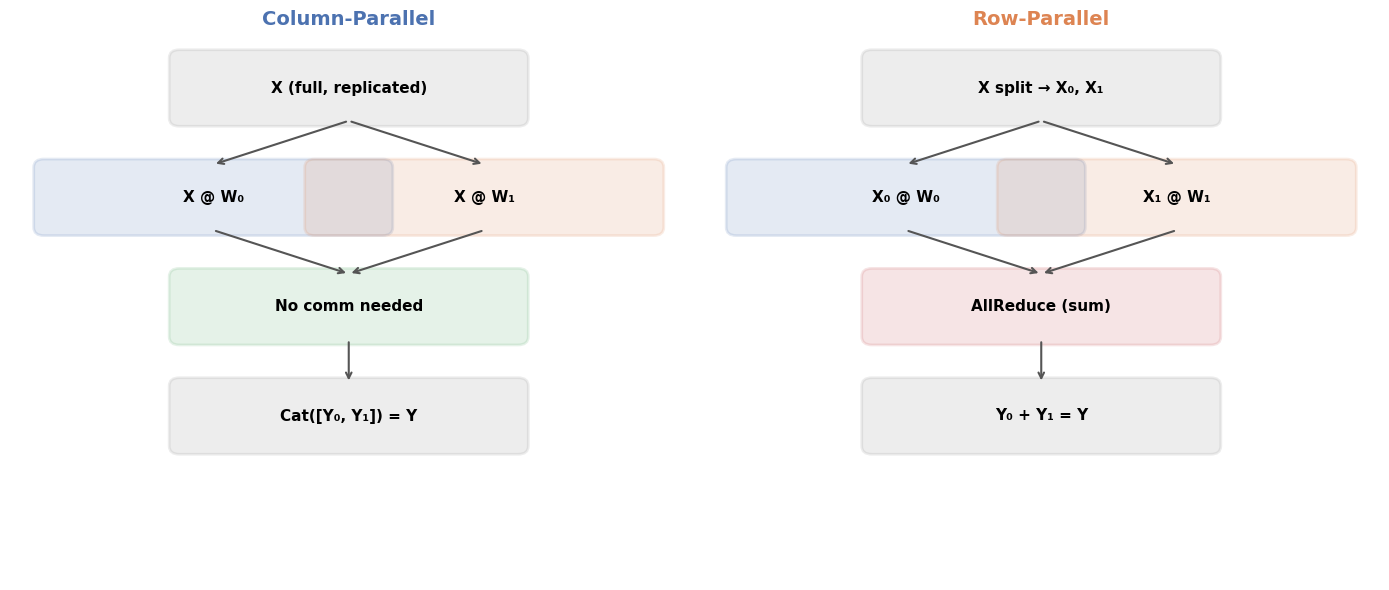

In [9]:
def draw_tp_comparison():
    """Side-by-side comparison of column-parallel vs row-parallel."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    for ax, mode in [(ax1, "column"), (ax2, "row")]:
        ax.set_xlim(0, 10)
        ax.set_ylim(0, 10)
        ax.axis("off")

        if mode == "column":
            ax.set_title("Column-Parallel", fontsize=14, fontweight="bold",
                        color=GPU_COLORS[0])
            steps = [
                (5, 9.0, "X (full, replicated)", "#888"),
                (3, 7.0, "X @ W₀", GPU_COLORS[0]),
                (7, 7.0, "X @ W₁", GPU_COLORS[1]),
                (5, 5.0, "No comm needed", "#55A868"),
                (5, 3.0, "Cat([Y₀, Y₁]) = Y", "#888"),
            ]
        else:
            ax.set_title("Row-Parallel", fontsize=14, fontweight="bold",
                        color=GPU_COLORS[1])
            steps = [
                (5, 9.0, "X split → X₀, X₁", "#888"),
                (3, 7.0, "X₀ @ W₀", GPU_COLORS[0]),
                (7, 7.0, "X₁ @ W₁", GPU_COLORS[1]),
                (5, 5.0, "AllReduce (sum)", "#C44E52"),
                (5, 3.0, "Y₀ + Y₁ = Y", "#888"),
            ]

        for x, y, text, color in steps:
            box = mpatches.FancyBboxPatch(
                (x - 2.5, y - 0.55), 5.0, 1.1,
                boxstyle="round,pad=0.15", facecolor=color, alpha=0.15,
                edgecolor=color, linewidth=2
            )
            ax.add_patch(box)
            ax.text(x, y, text, ha="center", va="center",
                    fontsize=11, fontweight="bold")

        # Arrows
        arrows = [(5, 8.4, 3, 7.6), (5, 8.4, 7, 7.6),
                  (3, 6.4, 5, 5.6), (7, 6.4, 5, 5.6),
                  (5, 4.4, 5, 3.6)]
        for x1, y1, x2, y2 in arrows:
            ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                       arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"))

    fig.tight_layout()
    return fig

fig = draw_tp_comparison()
plt.show()

| | Column-Parallel | Row-Parallel |
|---|---|---|
| **W split** | by columns | by rows |
| **X** | replicated (full) | split along last dim |
| **Each GPU output** | slice of Y's columns | partial sum (same shape as Y) |
| **Communication** | none (or AllGather) | **AllReduce** (sum) |

---
## 5. The Conjugate Pair: combining both for MLP

A Transformer **MLP (Multi-Layer Perceptron) block** is a small feed-forward network inside each Transformer layer — it has two linear layers with an activation function in between:

$$\text{MLP}(X) = \text{GeLU}(X \cdot W_1) \cdot W_2$$

**GeLU** (Gaussian Error Linear Unit) is an activation function — similar to ReLU but smoother. It introduces non-linearity so the network can learn complex patterns. The key thing for TP: GeLU is applied element-wise, so each GPU can apply it independently to its own slice.

Megatron's trick: use **Column-Parallel** for $W_1$, then **Row-Parallel** for $W_2$. The output of column-parallel is already split in exactly the right way to feed into row-parallel — **no communication between them!**

Let's trace through with real numbers.

In [10]:
# MLP: hidden=4 → intermediate=6 → hidden=4, on 3 GPUs
torch.manual_seed(7)
X  = (torch.randn(2, 4) * 2).round() / 2   # nice round-ish numbers
W1 = (torch.randn(4, 6) * 2).round() / 2
W2 = (torch.randn(6, 4) * 2).round() / 2

# Reference result
Y_ref = F.gelu(X @ W1) @ W2

print("Shapes: X(2×4) → W1(4×6) → GeLU → W2(6×4) → Y(2×4)")
print(f"3 GPUs: each gets 2 columns of W1, 2 rows of W2")

Shapes: X(2×4) → W1(4×6) → GeLU → W2(6×4) → Y(2×4)
3 GPUs: each gets 2 columns of W1, 2 rows of W2


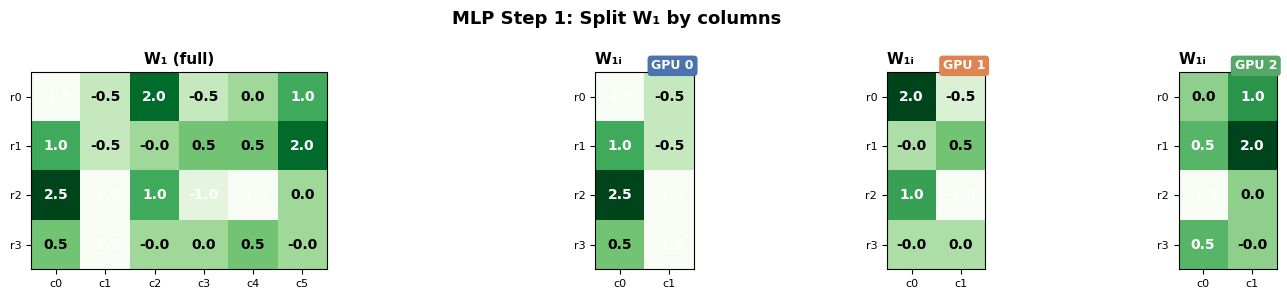

In [11]:
num_gpus = 3

# Step 1: Column-parallel on W1
W1_chunks = W1.chunk(num_gpus, dim=1)

fig, axes = plt.subplots(1, 4, figsize=(16, 3),
                         gridspec_kw={"width_ratios": [4, 2, 2, 2]})
show_matrix(W1, ax=axes[0], title="W₁ (full)", cmap="Greens")
for i, chunk in enumerate(W1_chunks):
    show_matrix(chunk, ax=axes[i+1], title=f"W₁ᵢ", gpu_label=f"GPU {i}", cmap="Greens")
fig.suptitle("MLP Step 1: Split W₁ by columns", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

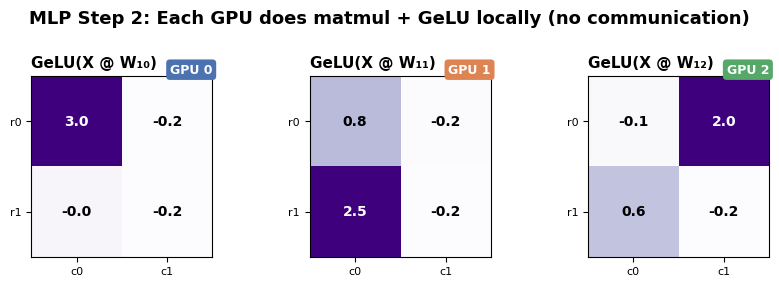

Each GPU has a (2×2) hidden activation — a SLICE of the intermediate.


In [12]:
# Step 2: Each GPU computes X @ W1_i, then applies GeLU locally
H_parts = [F.gelu(X @ W1_i) for W1_i in W1_chunks]

fig = show_matrices_row(
    H_parts,
    titles=["GeLU(X @ W₁₀)", "GeLU(X @ W₁₁)", "GeLU(X @ W₁₂)"],
    gpu_labels=["GPU 0", "GPU 1", "GPU 2"],
    suptitle="MLP Step 2: Each GPU does matmul + GeLU locally (no communication)",
    cmap="Purples"
)
plt.show()

print("Each GPU has a (2×2) hidden activation — a SLICE of the intermediate.")

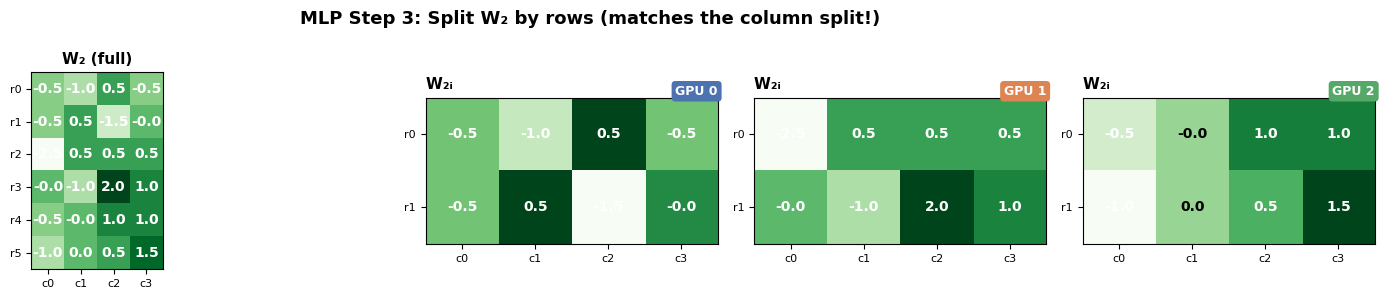

In [13]:
# Step 3: Row-parallel on W2 — split W2 by rows
# The column-parallel output is already split the right way!
W2_chunks = W2.chunk(num_gpus, dim=0)

fig, axes = plt.subplots(1, 4, figsize=(16, 3),
                         gridspec_kw={"width_ratios": [4, 2, 2, 2]})
show_matrix(W2, ax=axes[0], title="W₂ (full)", cmap="Greens")
for i, chunk in enumerate(W2_chunks):
    show_matrix(chunk, ax=axes[i+1], title=f"W₂ᵢ", gpu_label=f"GPU {i}", cmap="Greens")
fig.suptitle("MLP Step 3: Split W₂ by rows (matches the column split!)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

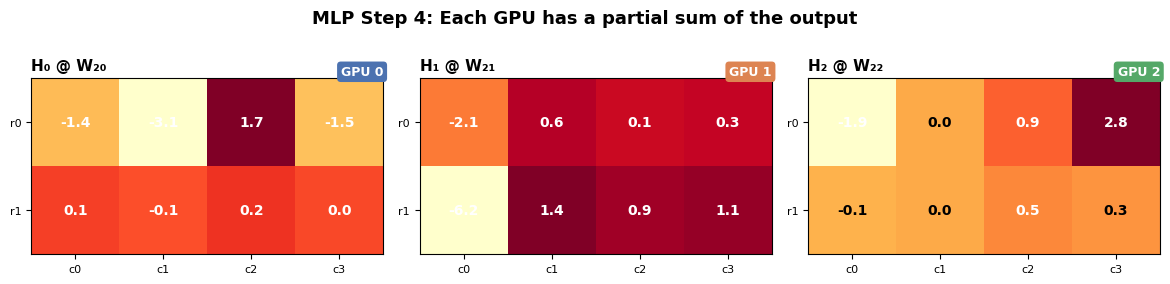

All three are (2×4) — same shape as final output. They need to be summed.


In [14]:
# Step 4: Each GPU computes H_i @ W2_i → partial output (same shape as final Y)
Y_parts = [H_i @ W2_i for H_i, W2_i in zip(H_parts, W2_chunks)]

fig = show_matrices_row(
    Y_parts,
    titles=["H₀ @ W₂₀", "H₁ @ W₂₁", "H₂ @ W₂₂"],
    gpu_labels=["GPU 0", "GPU 1", "GPU 2"],
    suptitle="MLP Step 4: Each GPU has a partial sum of the output"
)
plt.show()

print("All three are (2×4) — same shape as final output. They need to be summed.")

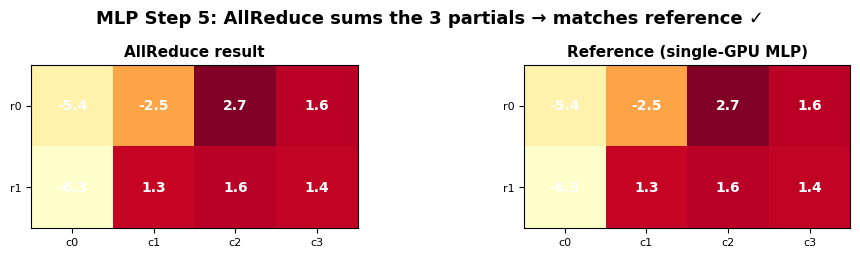

✓ TP MLP matches! Only 1 AllReduce for the entire MLP block.


In [15]:
# Step 5: AllReduce — the ONLY communication in the entire MLP!
Y_final = simulate_allreduce(Y_parts)

fig, axes = plt.subplots(1, 2, figsize=(10, 2.5))
show_matrix(Y_final[0], ax=axes[0], title="AllReduce result")
show_matrix(Y_ref,      ax=axes[1], title="Reference (single-GPU MLP)")
fig.suptitle("MLP Step 5: AllReduce sums the 3 partials → matches reference ✓",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

assert torch.allclose(Y_final[0], Y_ref, atol=1e-5)
print("✓ TP MLP matches! Only 1 AllReduce for the entire MLP block.")

### Why does this work?

The column-parallel output naturally feeds into row-parallel:

| Step | What happens | Communication |
|------|-------------|---------------|
| W₁ column-parallel | Each GPU gets columns of W₁, computes with full X | None |
| GeLU | Applied locally on each GPU's slice | None |
| W₂ row-parallel | Each GPU's slice is the right "row" input | None |
| AllReduce | Sum partial outputs to get final Y | **1 AllReduce** |

This is the **conjugate pair** — the cornerstone of Megatron-style TP.

> **Difficulty jump ahead:** The next section applies TP to self-attention, which involves Q/K/V projections and multi-head splitting. If you're new to attention mechanisms, just focus on the key insight: attention heads are *independent*, so they split across GPUs naturally — no extra communication needed.

---
## 6. Self-Attention: same pattern, different layer

**Multi-head self-attention** is the other key component of a Transformer layer (alongside the MLP). It lets the model look at all positions in a sequence and decide which ones are relevant to each other.

It works by projecting the input into three sets of vectors — **Q (Query)**, **K (Key)**, **V (Value)** — using separate weight matrices. The attention score between positions is computed as $\text{softmax}(QK^T / \sqrt{d})$, then used to weight the values $V$.

The "multi-head" part means this is done multiple times in parallel with different learned projections (called **heads**). Each head can attend to different patterns. Since heads are independent, they're perfect for TP — each GPU handles a subset of heads.

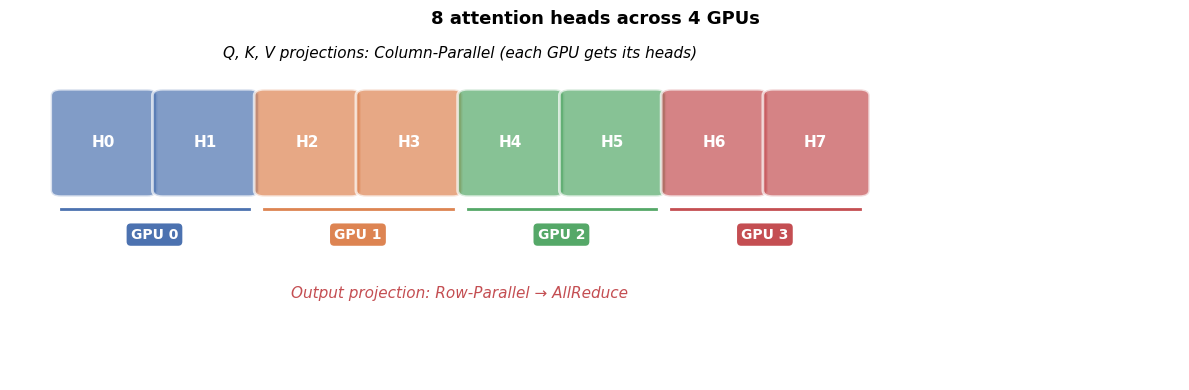

In [16]:
def draw_attention_tp(num_heads=8, num_gpus=4):
    """Visualize how attention heads are distributed across GPUs."""
    heads_per_gpu = num_heads // num_gpus

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_xlim(-0.5, num_heads + 3)
    ax.set_ylim(-1, 4.5)
    ax.axis("off")

    # Draw heads as colored boxes
    for h in range(num_heads):
        gpu = h // heads_per_gpu
        color = GPU_COLORS[gpu % len(GPU_COLORS)]
        rect = mpatches.FancyBboxPatch(
            (h, 2), 0.85, 1.5,
            boxstyle="round,pad=0.1", facecolor=color, alpha=0.7,
            edgecolor="white", linewidth=2
        )
        ax.add_patch(rect)
        ax.text(h + 0.42, 2.75, f"H{h}", ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")

    # GPU labels below
    for g in range(num_gpus):
        start = g * heads_per_gpu
        mid = start + heads_per_gpu / 2 - 0.08
        color = GPU_COLORS[g % len(GPU_COLORS)]
        ax.text(mid, 1.3, f"GPU {g}", ha="center", va="center",
                fontsize=10, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.3", fc=color, ec="none"))
        # Bracket
        ax.plot([start, start + heads_per_gpu - 0.15],
                [1.7, 1.7], color=color, linewidth=2)

    # Labels
    ax.text(num_heads / 2 - 0.08, 4.1,
            "Q, K, V projections: Column-Parallel (each GPU gets its heads)",
            ha="center", fontsize=11, fontstyle="italic")
    ax.text(num_heads / 2 - 0.08, 0.3,
            "Output projection: Row-Parallel → AllReduce",
            ha="center", fontsize=11, fontstyle="italic", color="#C44E52")

    ax.set_title(f"{num_heads} attention heads across {num_gpus} GPUs",
                fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig

fig = draw_attention_tp(num_heads=8, num_gpus=4)
plt.show()

In [17]:
# Simulate: 4 heads, hidden=8, head_dim=2, 2 GPUs
torch.manual_seed(0)
num_heads, head_dim, hidden = 4, 2, 8
num_gpus = 2
seq_len = 3

X = (torch.randn(seq_len, hidden) * 2).round() / 2

# Full Q, K, V projection weights: (hidden, num_heads * head_dim)
Wq = torch.randn(hidden, num_heads * head_dim)
Wk = torch.randn(hidden, num_heads * head_dim)
Wv = torch.randn(hidden, num_heads * head_dim)
Wo = torch.randn(num_heads * head_dim, hidden)  # output projection

# --- Reference: single-GPU attention ---
Q = X @ Wq  # (seq, num_heads*head_dim)
K = X @ Wk
V = X @ Wv

# Reshape to (num_heads, seq, head_dim) for attention
Q_heads = Q.view(seq_len, num_heads, head_dim).permute(1, 0, 2)
K_heads = K.view(seq_len, num_heads, head_dim).permute(1, 0, 2)
V_heads = V.view(seq_len, num_heads, head_dim).permute(1, 0, 2)

attn = torch.softmax(Q_heads @ K_heads.transpose(-2, -1) / head_dim**0.5, dim=-1)
attn_out = (attn @ V_heads).permute(1, 0, 2).reshape(seq_len, num_heads * head_dim)
Y_ref = attn_out @ Wo
print(f"Reference attention output shape: {Y_ref.shape}")

Reference attention output shape: torch.Size([3, 8])


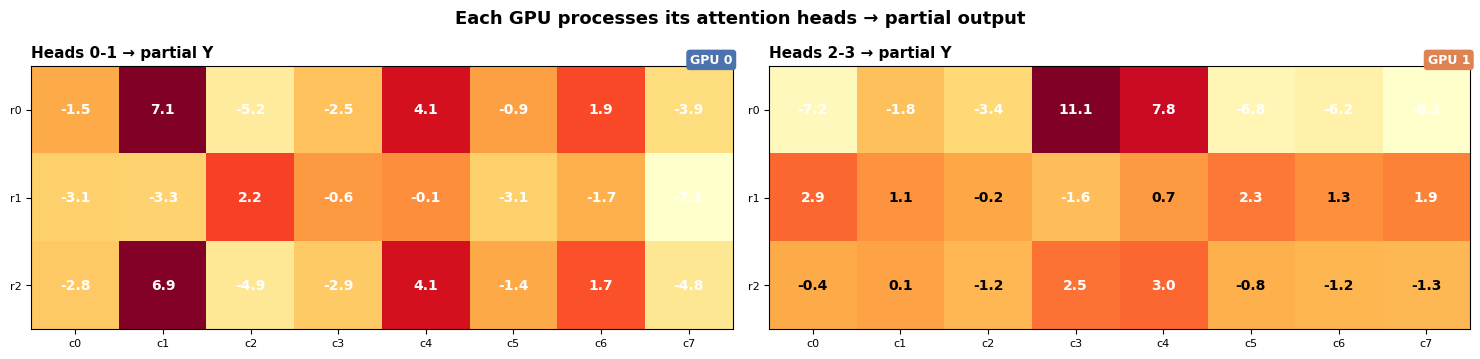

In [18]:
# --- TP attention: split heads across GPUs ---
heads_per_gpu = num_heads // num_gpus  # 2 heads per GPU

# Column-parallel: split Wq, Wk, Wv by columns (each GPU gets its heads' weights)
Wq_chunks = Wq.chunk(num_gpus, dim=1)
Wk_chunks = Wk.chunk(num_gpus, dim=1)
Wv_chunks = Wv.chunk(num_gpus, dim=1)
# Row-parallel: split Wo by rows
Wo_chunks = Wo.chunk(num_gpus, dim=0)

Y_parts = []
for g in range(num_gpus):
    # Each GPU computes its subset of heads
    Q_g = X @ Wq_chunks[g]  # (seq, heads_per_gpu * head_dim)
    K_g = X @ Wk_chunks[g]
    V_g = X @ Wv_chunks[g]

    Q_h = Q_g.view(seq_len, heads_per_gpu, head_dim).permute(1, 0, 2)
    K_h = K_g.view(seq_len, heads_per_gpu, head_dim).permute(1, 0, 2)
    V_h = V_g.view(seq_len, heads_per_gpu, head_dim).permute(1, 0, 2)

    attn_g = torch.softmax(Q_h @ K_h.transpose(-2, -1) / head_dim**0.5, dim=-1)
    out_g = (attn_g @ V_h).permute(1, 0, 2).reshape(seq_len, heads_per_gpu * head_dim)

    # Row-parallel output projection → partial result
    Y_parts.append(out_g @ Wo_chunks[g])

fig = show_matrices_row(
    Y_parts,
    titles=["Heads 0-1 → partial Y", "Heads 2-3 → partial Y"],
    gpu_labels=["GPU 0", "GPU 1"],
    suptitle="Each GPU processes its attention heads → partial output"
)
plt.show()

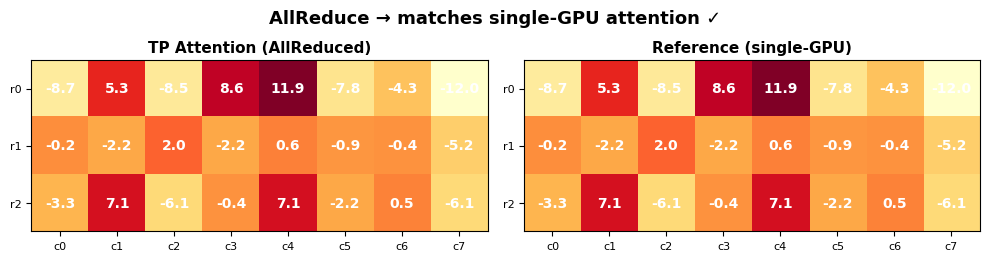

✓ TP attention matches! Same pattern: column-parallel → local compute → row-parallel → AllReduce


In [19]:
# AllReduce to get final result
Y_tp = simulate_allreduce(Y_parts)

fig, axes = plt.subplots(1, 2, figsize=(10, 2.5))
show_matrix(Y_tp[0], ax=axes[0], title="TP Attention (AllReduced)")
show_matrix(Y_ref,   ax=axes[1], title="Reference (single-GPU)")
fig.suptitle("AllReduce → matches single-GPU attention ✓", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

assert torch.allclose(Y_tp[0], Y_ref, atol=1e-5)
print("✓ TP attention matches! Same pattern: column-parallel → local compute → row-parallel → AllReduce")

---
## 7. Putting it all together: one Transformer layer

Each Transformer layer has an attention block and an MLP block. With TP, each needs exactly **one AllReduce**.

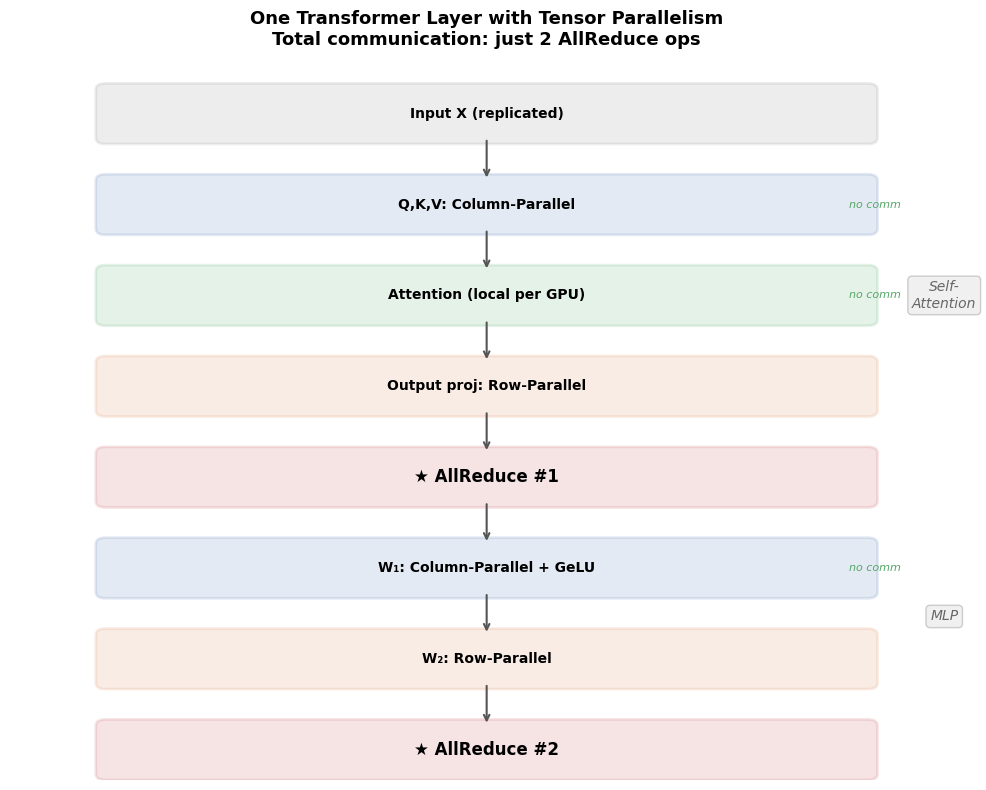

In [20]:
def draw_transformer_tp_flow():
    """Visualize communication pattern in one TP Transformer layer."""
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.axis("off")

    blocks = [
        # (x, y, w, h, text, color, comm_label)
        (5, 11,  8, 0.8, "Input X (replicated)", "#888", None),
        (5, 9.5, 8, 0.8, "Q,K,V: Column-Parallel", GPU_COLORS[0], "no comm"),
        (5, 8.0, 8, 0.8, "Attention (local per GPU)", GPU_COLORS[2], "no comm"),
        (5, 6.5, 8, 0.8, "Output proj: Row-Parallel", GPU_COLORS[1], None),
        (5, 5.0, 8, 0.8, "★ AllReduce #1", "#C44E52", None),
        (5, 3.5, 8, 0.8, "W₁: Column-Parallel + GeLU", GPU_COLORS[0], "no comm"),
        (5, 2.0, 8, 0.8, "W₂: Row-Parallel", GPU_COLORS[1], None),
        (5, 0.5, 8, 0.8, "★ AllReduce #2", "#C44E52", None),
    ]

    section_labels = [
        (9.8, 8.0, "Self-\nAttention"),
        (9.8, 2.7, "MLP"),
    ]

    for x, y, w, h, text, color, comm in blocks:
        box = mpatches.FancyBboxPatch(
            (x - w/2, y - h/2), w, h,
            boxstyle="round,pad=0.1", facecolor=color, alpha=0.15,
            edgecolor=color, linewidth=2
        )
        ax.add_patch(box)
        fs = 12 if "★" in text else 10
        fw = "bold" if "★" in text else "bold"
        ax.text(x, y, text, ha="center", va="center", fontsize=fs, fontweight=fw)
        if comm:
            ax.text(x + w/2 - 0.2, y, comm, ha="left", va="center",
                    fontsize=8, fontstyle="italic", color="#55A868")

    # Arrows
    for i in range(len(blocks) - 1):
        y1 = blocks[i][1] - blocks[i][3]/2
        y2 = blocks[i+1][1] + blocks[i+1][3]/2
        ax.annotate("", xy=(5, y2), xytext=(5, y1),
                   arrowprops=dict(arrowstyle="->", lw=1.5, color="#555"))

    for x, y, text in section_labels:
        ax.text(x, y, text, ha="center", va="center", fontsize=10,
                fontstyle="italic", color="#666",
                bbox=dict(boxstyle="round", fc="#f0f0f0", ec="#ccc"))

    ax.set_title("One Transformer Layer with Tensor Parallelism\n"
                 "Total communication: just 2 AllReduce ops",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig

fig = draw_transformer_tp_flow()
plt.show()

---
## 8. Application in LLMs

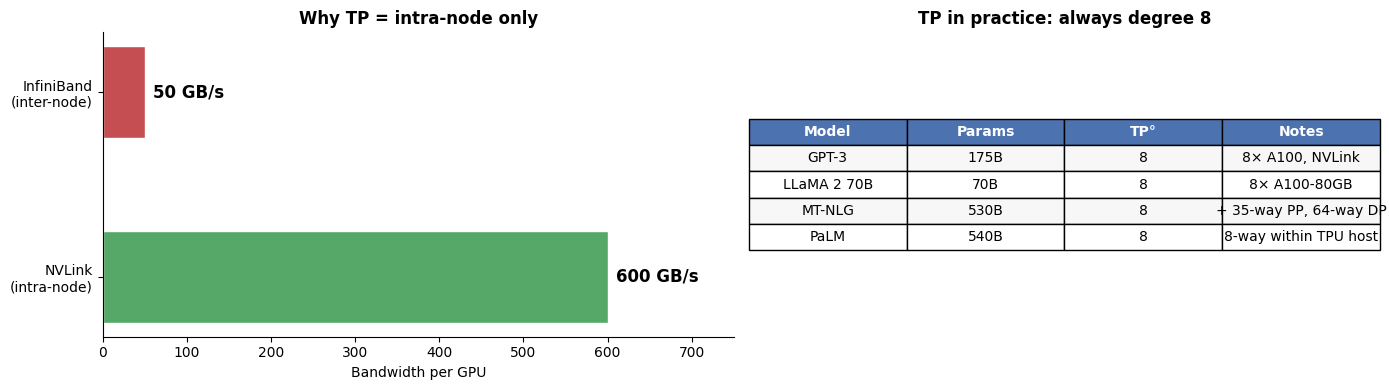

In [21]:
def draw_tp_in_practice():
    """Visualize why TP stays within one node."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: bandwidth comparison
    ax = axes[0]
    labels = ["NVLink\n(intra-node)", "InfiniBand\n(inter-node)"]
    bw = [600, 50]
    colors = ["#55A868", "#C44E52"]
    bars = ax.barh(labels, bw, color=colors, height=0.5, edgecolor="white")
    for bar, val in zip(bars, bw):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                f"{val} GB/s", va="center", fontsize=12, fontweight="bold")
    ax.set_xlim(0, 750)
    ax.set_xlabel("Bandwidth per GPU", fontsize=10)
    ax.set_title("Why TP = intra-node only", fontsize=12, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Right: model configurations
    ax = axes[1]
    ax.axis("off")
    table_data = [
        ["GPT-3",       "175B", "8",  "8× A100, NVLink"],
        ["LLaMA 2 70B", "70B",  "8",  "8× A100-80GB"],
        ["MT-NLG",      "530B", "8",  "+ 35-way PP, 64-way DP"],
        ["PaLM",        "540B", "8",  "8-way within TPU host"],
    ]
    table = ax.table(
        cellText=table_data,
        colLabels=["Model", "Params", "TP°", "Notes"],
        loc="center", cellLoc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.6)
    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_facecolor("#4C72B0")
            cell.set_text_props(color="white", fontweight="bold")
        else:
            cell.set_facecolor("#f7f7f7" if r % 2 else "white")
    ax.set_title("TP in practice: always degree 8", fontsize=12, fontweight="bold")

    fig.tight_layout()
    return fig

fig = draw_tp_in_practice()
plt.show()

TP degree is almost always **8** — limited to one node's GPUs connected by **NVLink** (NVIDIA's high-speed GPU-to-GPU interconnect, ~600 GB/s). Cross-node connections use **InfiniBand** (~50 GB/s) — 12× slower, too slow for TP's frequent AllReduce calls.

For scaling beyond one node, combine TP with **Pipeline Parallelism** (PP — split the model by layers across nodes) and **Data Parallelism** (DP — each node processes different data batches).

---
## 9. GPU-Required: real multi-GPU TP

> **GPU Required** — Run this cell on a multi-GPU machine (4+ GPUs recommended).

In [ ]:
# [GPU-REQUIRED]
# Real multi-GPU tensor parallelism using torch.distributed + NCCL
# Run on a multi-GPU machine (4+ GPUs recommended)

import torch
import torch.distributed as dist
import torch.multiprocessing as mp
import torch.nn.functional as F
import os

def tp_mlp_worker(rank, world_size, X_shared, W1_shared, W2_shared, results):
    """Worker function for one GPU in tensor-parallel MLP."""
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "29500"
    dist.init_process_group("nccl", rank=rank, world_size=world_size)

    device = torch.device(f"cuda:{rank}")
    X = X_shared.to(device)

    # Column-parallel W1
    chunk_size = W1_shared.shape[1] // world_size
    W1_local = W1_shared[:, rank * chunk_size:(rank + 1) * chunk_size].to(device)

    # Row-parallel W2
    row_chunk = W2_shared.shape[0] // world_size
    W2_local = W2_shared[rank * row_chunk:(rank + 1) * row_chunk, :].to(device)

    # Forward: column-parallel → GeLU → row-parallel → AllReduce
    hidden = F.gelu(X @ W1_local)
    output = hidden @ W2_local
    dist.all_reduce(output, op=dist.ReduceOp.SUM)

    if rank == 0:
        results["output"] = output.cpu()
    dist.destroy_process_group()

if torch.cuda.is_available() and torch.cuda.device_count() >= 4:
    world_size = 4
    hidden, intermediate = 64, 256
    X = torch.randn(2, 8, hidden)
    W1 = torch.randn(hidden, intermediate)
    W2 = torch.randn(intermediate, hidden)

    Y_ref = F.gelu(X @ W1) @ W2

    manager = mp.Manager()
    results = manager.dict()
    mp.spawn(tp_mlp_worker, args=(world_size, X, W1, W2, results), nprocs=world_size)

    Y_tp = results["output"]
    print(f"Max error: {(Y_tp - Y_ref).abs().max().item():.2e}")
    print("✓ Real multi-GPU TP MLP matches reference!")
else:
    print("Skipping: requires 4 CUDA GPUs")

---
## 10. Megatron-LM Reference

Megatron-LM is the canonical production TP implementation. The two key classes:

In [22]:
from mp_tutorial.formatting import code_reference

code_reference(
    code="""
class ColumnParallelLinear(torch.nn.Module):
    \"\"\"Y = XA + b, with A split by columns: A = [A_1, ..., A_p]\"\"\"

    def __init__(self, input_size, output_size, *, gather_output=True, ...):
        self.output_size_per_partition = divide(output_size, world_size)
        self.weight = Parameter(torch.empty(
            self.output_size_per_partition, input_size))  # transposed!

    def forward(self, input_):
        # Identity in fwd, AllReduce in bwd
        input_parallel = copy_to_tensor_model_parallel_region(input_)
        output_parallel = F.linear(input_parallel, self.weight, self.bias)
        if self.gather_output:
            output = gather_from_tensor_model_parallel_region(output_parallel)
        else:
            output = output_parallel  # keep split for next layer
        return output
""",
    source="Megatron-LM",
    filepath="megatron/core/tensor_parallel/layers.py"
)

In [23]:
code_reference(
    code="""
class RowParallelLinear(torch.nn.Module):
    \"\"\"Y = XA + b, with A split by rows and X by columns\"\"\"

    def __init__(self, input_size, output_size, *, input_is_parallel=False, ...):
        self.input_size_per_partition = divide(input_size, world_size)
        self.weight = Parameter(torch.empty(
            output_size, self.input_size_per_partition))

    def forward(self, input_):
        if self.input_is_parallel:
            input_parallel = input_  # already split from column-parallel
        else:
            input_parallel = scatter_to_tensor_model_parallel_region(input_)
        output_parallel = F.linear(input_parallel, self.weight)
        # AllReduce in fwd, identity in bwd
        output_ = reduce_from_tensor_model_parallel_region(output_parallel)
        return output_ + self.bias if self.bias is not None else output_
""",
    source="Megatron-LM",
    filepath="megatron/core/tensor_parallel/layers.py"
)

`mappings.py` defines communication primitives as custom autograd functions — each is a **conjugate pair** for correct gradient flow:

| Forward | Backward | Used by |
|---------|----------|---------|
| Identity | AllReduce | `CopyToModelParallelRegion` (column-parallel input) |
| AllReduce | Identity | `ReduceFromModelParallelRegion` (row-parallel output) |
| Split | AllGather | `ScatterToModelParallelRegion` |
| AllGather | Split | `GatherFromModelParallelRegion` |

---
## Summary & Further Reading

### Key Takeaways

1. **Column-parallel** splits $W$ by columns → no communication in forward
2. **Row-parallel** splits $W$ by rows → needs AllReduce to sum partials
3. The **conjugate pair** (column → row) needs only **1 AllReduce** per block
4. Each Transformer layer: 1 AllReduce for attention + 1 for MLP = **2 total**
5. TP degree ≈ **8** (stays within one NVLink-connected node)
6. Self-attention maps naturally: each GPU gets a subset of **attention heads**

### Further Reading

- [Megatron-LM: Training Multi-Billion Parameter Language Models Using Model Parallelism](https://arxiv.org/abs/1909.08053)
- [Efficient Large-Scale Language Model Training on GPU Clusters](https://arxiv.org/abs/2104.04473) — 3D parallelism (TP + PP + DP)
- [PyTorch Distributed Docs](https://pytorch.org/docs/stable/distributed.html)
- [NVIDIA Megatron-Core](https://github.com/NVIDIA/Megatron-LM)
- Next: [03-pipeline-parallelism/](03-pipeline-parallelism.ipynb) — splitting by layers across GPUs